# 08. Model Classification: Training - Pandas

## 08.1. Importação das bibliotecas

### 08.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
import warnings

### 08.1.2. Importando as bibliotecas de terceiros

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler

### 08.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 08.2. Visão geral dos dados

### 08.2.1. Habilitando a exibição de todas as colunas

In [4]:
pd.set_option('display.max_columns', None)

### 08.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLUSTERED_PANDAS)

### 08.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(2205, 23)

### 08.2.4. Exibindo o dataset

In [7]:
df.head(5)

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,1,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,0,2


### 08.2.5. Visualizando os detalhes do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Education             2205 non-null   object  
 1   Marital_Status        2205 non-null   object  
 2   Children              2205 non-null   int64   
 3   HasChildren           2205 non-null   int64   
 4   Age                   2205 non-null   int64   
 5   AgeGroup              2205 non-null   category
 6   Income                2205 non-null   float64 
 7   Recency               2205 non-null   int64   
 8   Complain              2205 non-null   int64   
 9   Dt_Customer_Month     2205 non-null   int64   
 10  Dt_Customer_Quarter   2205 non-null   int64   
 11  Days_Since_Enrolled   2205 non-null   int64   
 12  Years_Since_Enrolled  2205 non-null   int64   
 13  NumDealsPurchases     2205 non-null   int64   
 14  NumWebVisitsMonth     2205 non-null   int64   
 15  NumT

### 08.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,Children,HasChildren,Age,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
count,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00
mean,0.95,0.72,45.10,51622.09,49.01,0.01,6.47,2.48,353.72,0.48,2.32,5.34,12.57,562.76,44.06,606.82,0.30,0.21,0.15,1.09
std,0.75,0.45,11.71,20713.06,28.93,0.09,3.49,1.14,202.56,0.50,1.89,2.41,7.18,575.94,51.74,601.68,0.68,0.41,0.36,0.76
min,0.00,0.00,18.00,1730.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,5.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,37.00,35196.00,24.00,0.00,3.00,1.00,180.00,0.00,1.00,3.00,6.00,56.00,9.00,69.00,0.00,0.00,0.00,1.00
50%,1.00,1.00,44.00,51287.00,49.00,0.00,6.00,2.00,356.00,0.00,2.00,6.00,12.00,343.00,25.00,397.00,0.00,0.00,0.00,1.00
75%,1.00,1.00,55.00,68281.00,74.00,0.00,10.00,4.00,529.00,1.00,3.00,7.00,18.00,964.00,56.00,1047.00,0.00,0.00,0.00,2.00
max,3.00,1.00,74.00,113734.00,99.00,1.00,12.00,4.00,699.00,1.00,15.00,20.00,32.00,2491.00,321.00,2525.00,4.00,1.00,1.00,2.00


### 08.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,Education,Marital_Status,AgeGroup
count,2205,2205,2205
unique,5,2,4
top,Graduation,Partner,31-45
freq,1113,1422,958


### 08.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

Education               0
Marital_Status          0
Children                0
HasChildren             0
Age                     0
AgeGroup                0
Income                  0
Recency                 0
Complain                0
Dt_Customer_Month       0
Dt_Customer_Quarter     0
Days_Since_Enrolled     0
Years_Since_Enrolled    0
NumDealsPurchases       0
NumWebVisitsMonth       0
NumTotalPurchases       0
MntRegularProds         0
MntGoldProds            0
MntTotal                0
AcceptedCmpTotal        0
HasAcceptedCmp          0
Response                0
Cluster                 0
dtype: int64

### 08.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

Education                  5
Marital_Status             2
Children                   4
HasChildren                2
Age                       56
AgeGroup                   4
Income                  1963
Recency                  100
Complain                   2
Dt_Customer_Month         12
Dt_Customer_Quarter        4
Days_Since_Enrolled      662
Years_Since_Enrolled       2
NumDealsPurchases         15
NumWebVisitsMonth         16
NumTotalPurchases         33
MntRegularProds          897
MntGoldProds             212
MntTotal                1045
AcceptedCmpTotal           5
HasAcceptedCmp             2
Response                   2
Cluster                    3
dtype: int64

### 08.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

185

### 08.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 20
- Categoric Columns: 2
- Date Columns: 0


## 08.3. Treinamento do modelo de classificação

### 08.3.1. Definindo os valores de X e y

In [15]:
X = df.drop('Response', axis = 1)

X.head(5)

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,2


In [16]:
y = df['Response']

y.head(5)

0    1
1    0
2    0
3    0
4    0
Name: Response, dtype: int64

### 08.3.2. Listando as colunas numéricas e categóricas

In [17]:
numerical_features = X.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- Children
- HasChildren
- Age
- Income
- Recency
- Complain
- Dt_Customer_Month
- Dt_Customer_Quarter
- Days_Since_Enrolled
- Years_Since_Enrolled
- NumDealsPurchases
- NumWebVisitsMonth
- NumTotalPurchases
- MntRegularProds
- MntGoldProds
- MntTotal
- AcceptedCmpTotal
- HasAcceptedCmp
- Cluster


In [18]:
categorical_features = X.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- Education
- Marital_Status
- AgeGroup


### 08.3.3. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


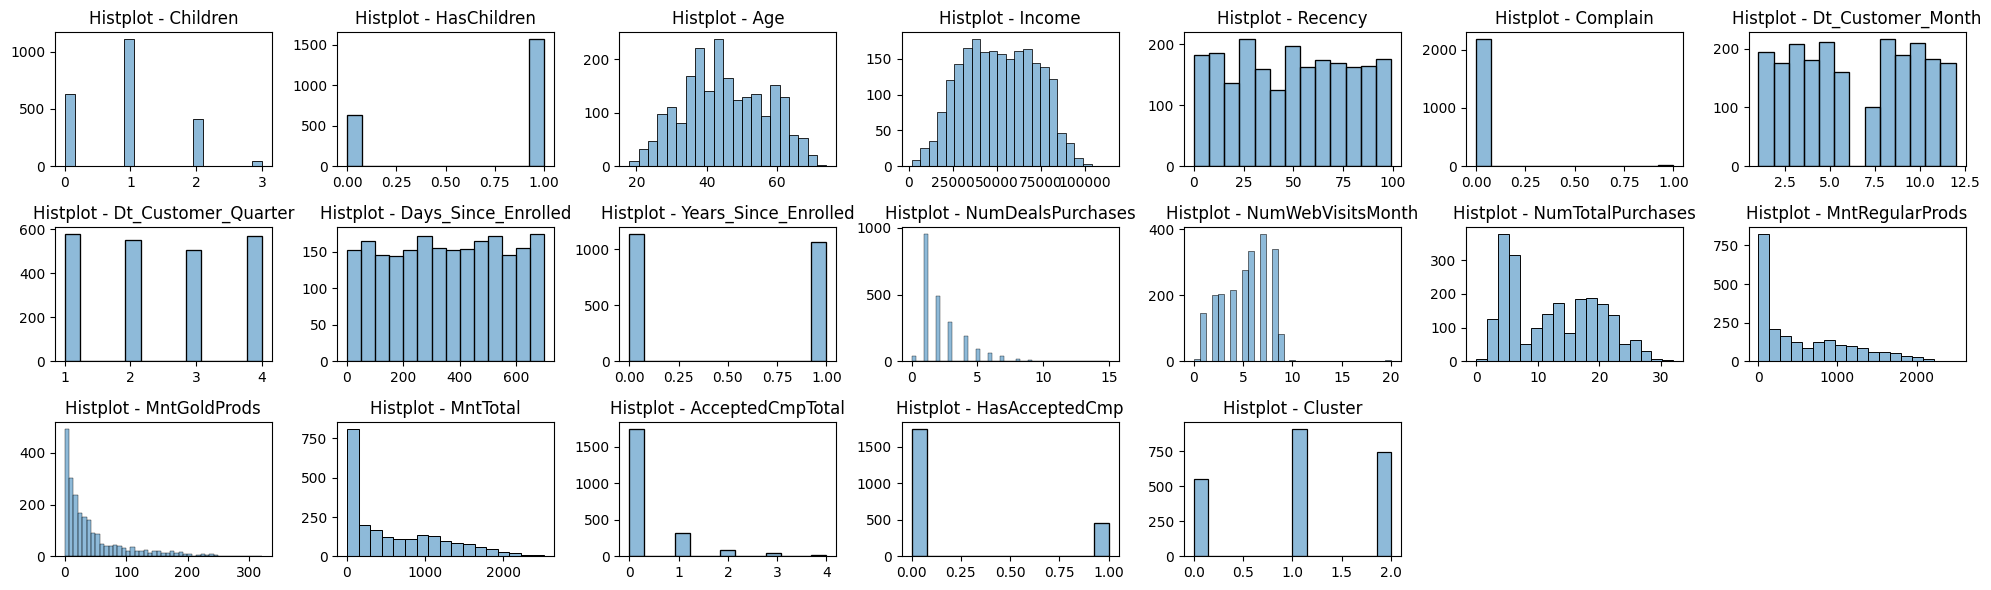

In [19]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb08_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 08.3.4. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Standard Scaler:** Indicado para colunas com distribuição semelhante à normal.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [20]:
one_hot_encoder_columns = [
    'Education',
    'Marital_Status',
    'AgeGroup',
    'Children',
    'HasChildren',
    'Complain',
    'Years_Since_Enrolled',
    'AcceptedCmpTotal',
    'HasAcceptedCmp',
    'Cluster',
]

standard_scaler_columns = [
    'Income',
    'Age',
]

power_transformer_columns = [
   'NumDealsPurchases',
   'NumWebVisitsMonth',
   'NumTotalPurchases',
   'MntRegularProds',
   'MntGoldProds',
   'MntTotal',
]

min_max_scaler_columns = [
    'Recency',
    'Dt_Customer_Month',
    'Dt_Customer_Quarter',
    'Days_Since_Enrolled',
]

### 08.3.5. Definindo os pré processamentos que serão aplicados nas colunas

In [21]:
pre_processing = ColumnTransformer([

    ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

    ('standard_scaler', StandardScaler(), standard_scaler_columns),

    ('power_transformer', PowerTransformer(), power_transformer_columns),

    ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)

])

### 08.3.6. Criando o pipeline inicial

In [22]:
pipeline_initial = Pipeline([
        
    ('pre_processing', pre_processing),

    ('feature_selection', SelectKBest(score_func = f_classif, k = 10)),
    
    ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),
    
    ('models', LogisticRegression(random_state = consts.RANDOM_STATE)),
    
])

### 08.3.7. Treinando o modelo inicial

In [23]:
pipeline_initial.fit(X, y)

Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'Children', 'HasChildren',
                                                   'Complain',
                                                   'Years_Since_Enrolled',
                                                   'AcceptedCmpTotal',
                                                   'HasAcceptedCmp',
                                                   'Cluster']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Income', 'Age']),
                                                 ('power_transformer',
                                                  PowerTransformer(),
                                                  ['NumDealsPurchases',
                                                   'NumWebVisitsMonth',
                                                   'NumTotalPurchases',
                                                   'MntRegularProds',
                                                   'MntGoldProds',
                                                   'MntTotal']),
                                                 ('min_max_scaler',
                                                  MinMaxScaler(),
                                                  ['Recency',
                                                   'Dt_Customer_Month',
                                                   'Dt_Customer_Quarter',
                                                   'Days_Since_Enrolled'])])),
                ('feature_selection', SelectKBest()),
                ('resampling', RandomUnderSampler(random_state=42)),
                ('models', LogisticRegression(random_state=42))])

### 08.3.8. Aplicando o pipeline no modelo inicial

In [24]:
scores_initial = cross_validate(

    pipeline_initial,

    X,

    y,

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = consts.RANDOM_STATE),
    
    scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'],
    
    n_jobs = -2,

)

## 08.4. Otimização dos hiperparâmetros

### 08.4.1. Definindo o Grid Search

In [25]:
grid_search = GridSearchCV(

    Pipeline([
            
        ('pre_processing', pre_processing),

        ('feature_selection', SelectKBest(score_func = f_classif, k = 10)),
        
        ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),
        
        ('models', LogisticRegression(random_state = consts.RANDOM_STATE)),
        
    ]),
    
    {

        'feature_selection__k': [10, 15, 20, 25],

        'models__C': np.logspace(-3, 3, 7),

        'models__solver': ['liblinear', 'lbfgs', 'saga'],

        'models__penalty': ['l1', 'l2', 'elasticnet', 'none']
        
    },
    
    scoring = ['roc_auc', 'average_precision', 'accuracy'],
    
    n_jobs = -2,
    
    refit = 'average_precision'

)

### 08.4.2. Encontrando a melhor combinação de hiperparâmetros

In [26]:
warnings.filterwarnings('ignore')

grid_search.fit(X, y)

GridSearchCV(estimator=Pipeline(steps=[('pre_processing',
                                        ColumnTransformer(transformers=[('one_hot_encoder',
                                                                         OneHotEncoder(),
                                                                         ['Education',
                                                                          'Marital_Status',
                                                                          'AgeGroup',
                                                                          'Children',
                                                                          'HasChildren',
                                                                          'Complain',
                                                                          'Years_Since_Enrolled',
                                                                          'AcceptedCmpTotal',
                                                                          'HasAcceptedCmp',
                                                                          'Cluster']),
                                                                        ('standard_scaler',
                                                                         StandardScaler(),
                                                                         ['Income',
                                                                          'Age']),
                                                                        ('power_transformer',
                                                                         Pow...
                                       ('models',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-2,
             param_grid={'feature_selection__k': [10, 15, 20, 25],
                         'models__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'models__penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'models__solver': ['liblinear', 'lbfgs', 'saga']},
             refit='average_precision',
             scoring=['roc_auc', 'average_precision', 'accuracy'])

### 08.4.3. Listando os melhores hiperparâmetros

In [27]:
grid_search.best_params_

{'feature_selection__k': 25,
 'models__C': np.float64(10.0),
 'models__penalty': 'l1',
 'models__solver': 'saga'}

## 08.5. Treinamento otimizado do modelo de classificação

### 08.5.1. Criando o pipeline final

In [28]:
pipeline_final = Pipeline([

    ('pre_processing', pre_processing),

    ('feature_selection', SelectKBest(score_func = f_classif, k = grid_search.best_params_['feature_selection__k'])),

    ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),
    
    ('models', LogisticRegression(

        random_state = consts.RANDOM_STATE,

        C = grid_search.best_params_['models__C'],

        penalty = grid_search.best_params_['models__penalty'],

        solver = grid_search.best_params_['models__solver'],

    )),
    
])

### 08.5.2. Treinando o modelo final

In [29]:
pipeline_final.fit(X, y)

Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'Children', 'HasChildren',
                                                   'Complain',
                                                   'Years_Since_Enrolled',
                                                   'AcceptedCmpTotal',
                                                   'HasAcceptedCmp',
                                                   'Cluster']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Income', 'Age']),
                                                 ('power_transformer',
                                                  PowerTransformer(),
                                                  ['NumDe...
                                                   'NumTotalPurchases',
                                                   'MntRegularProds',
                                                   'MntGoldProds',
                                                   'MntTotal']),
                                                 ('min_max_scaler',
                                                  MinMaxScaler(),
                                                  ['Recency',
                                                   'Dt_Customer_Month',
                                                   'Dt_Customer_Quarter',
                                                   'Days_Since_Enrolled'])])),
                ('feature_selection', SelectKBest(k=25)),
                ('resampling', RandomUnderSampler(random_state=42)),
                ('models',
                 LogisticRegression(C=np.float64(10.0), penalty='l1',
                                    random_state=42, solver='saga'))])

### 08.5.3. Aplicando o pipeline no modelo final

In [30]:
scores_final = cross_validate(

    pipeline_final,
    
    X,
    
    y,

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = consts.RANDOM_STATE),

    scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'],
    
    n_jobs = -2,

)

### 08.5.4. Evitando overfitting do modelo

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Balanceamento de Classes:** No aspecto de Balanceamento de Classes, como o dataset do projeto é desbalanceado, foi aplicado a técnica de Random Under Sampling (RUS) para se equiparar os valores da classe target ('Response'), onde se reduz a quantidade de valores da classe majoritária até que fique igual aos valores da classe minoritária.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o Stratified K-Fold, por ser um dataset desbalanceado, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.
- **Regularização:** No aspecto de Regularização, foi aplicado a regularização L2 (Ridge) para adicionar uma penalidade ao modelo com base no coeficientes dos parâmetros, de modo que os coeficientes se tornem muito grandes e assim reduzindo o overfitting.
- **Otimização de Hiperparâmetros:** No aspecto de Otimização de Hiperparâmetros, foi aplicado o Grid Search para se combinar os melhores parâmetros das etapas do pipeline, de modo que se obtenha os melhores resultados nas métricas de avaliação para ter um modelo com boa performance e evitar o overfitting.

## 08.6. Comparação entre versões

### 08.6.1. Criando um dataset com as métricas iniciais e finais do treinamento do modelo

In [31]:
df_metrics = pd.concat([

    pd.DataFrame(scores_initial).assign(time = lambda df: df['fit_time'] + df['score_time'], results = 'initial'),

    pd.DataFrame(scores_final).assign(time = lambda df: df['fit_time'] + df['score_time'], results = 'final'),
    
], ignore_index = True)

df_metrics = df_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_metrics = df_metrics.drop(columns = ['fit_time', 'score_time'])

df_metrics = df_metrics.reindex(columns = ['results', 'accuracy', 'precision', 'recall', 'roc_auc', 'average_precision', 'time'])

df_metrics

,results,accuracy,precision,recall,roc_auc,average_precision,time
0,initial,0.784580,0.351064,0.492537,0.725337,0.405243,0.076053
1,initial,0.775510,0.357143,0.597015,0.771690,0.479887,0.120748
2,initial,0.807256,0.415094,0.656716,0.798667,0.447116,0.103995
3,initial,0.791383,0.393443,0.727273,0.842727,0.539000,0.126542
4,initial,0.736961,0.337662,0.787879,0.832182,0.500177,0.104999
5,final,0.789116,0.401515,0.791045,0.882293,0.620573,0.115303
6,final,0.775510,0.366667,0.656716,0.826443,0.566621,0.121419
7,final,0.804989,0.430657,0.880597,0.888798,0.602090,0.119468
8,final,0.802721,0.414634,0.772727,0.879414,0.637810,0.103474
9,final,0.789116,0.398496,0.803030,0.877798,0.617831,0.088776


### 08.6.2. Criando diagramas de caixa para comparar as métricas do modelo antes e depois da otimização de hiperparâmetros

- Gráfico: Diagrama de Caixa.


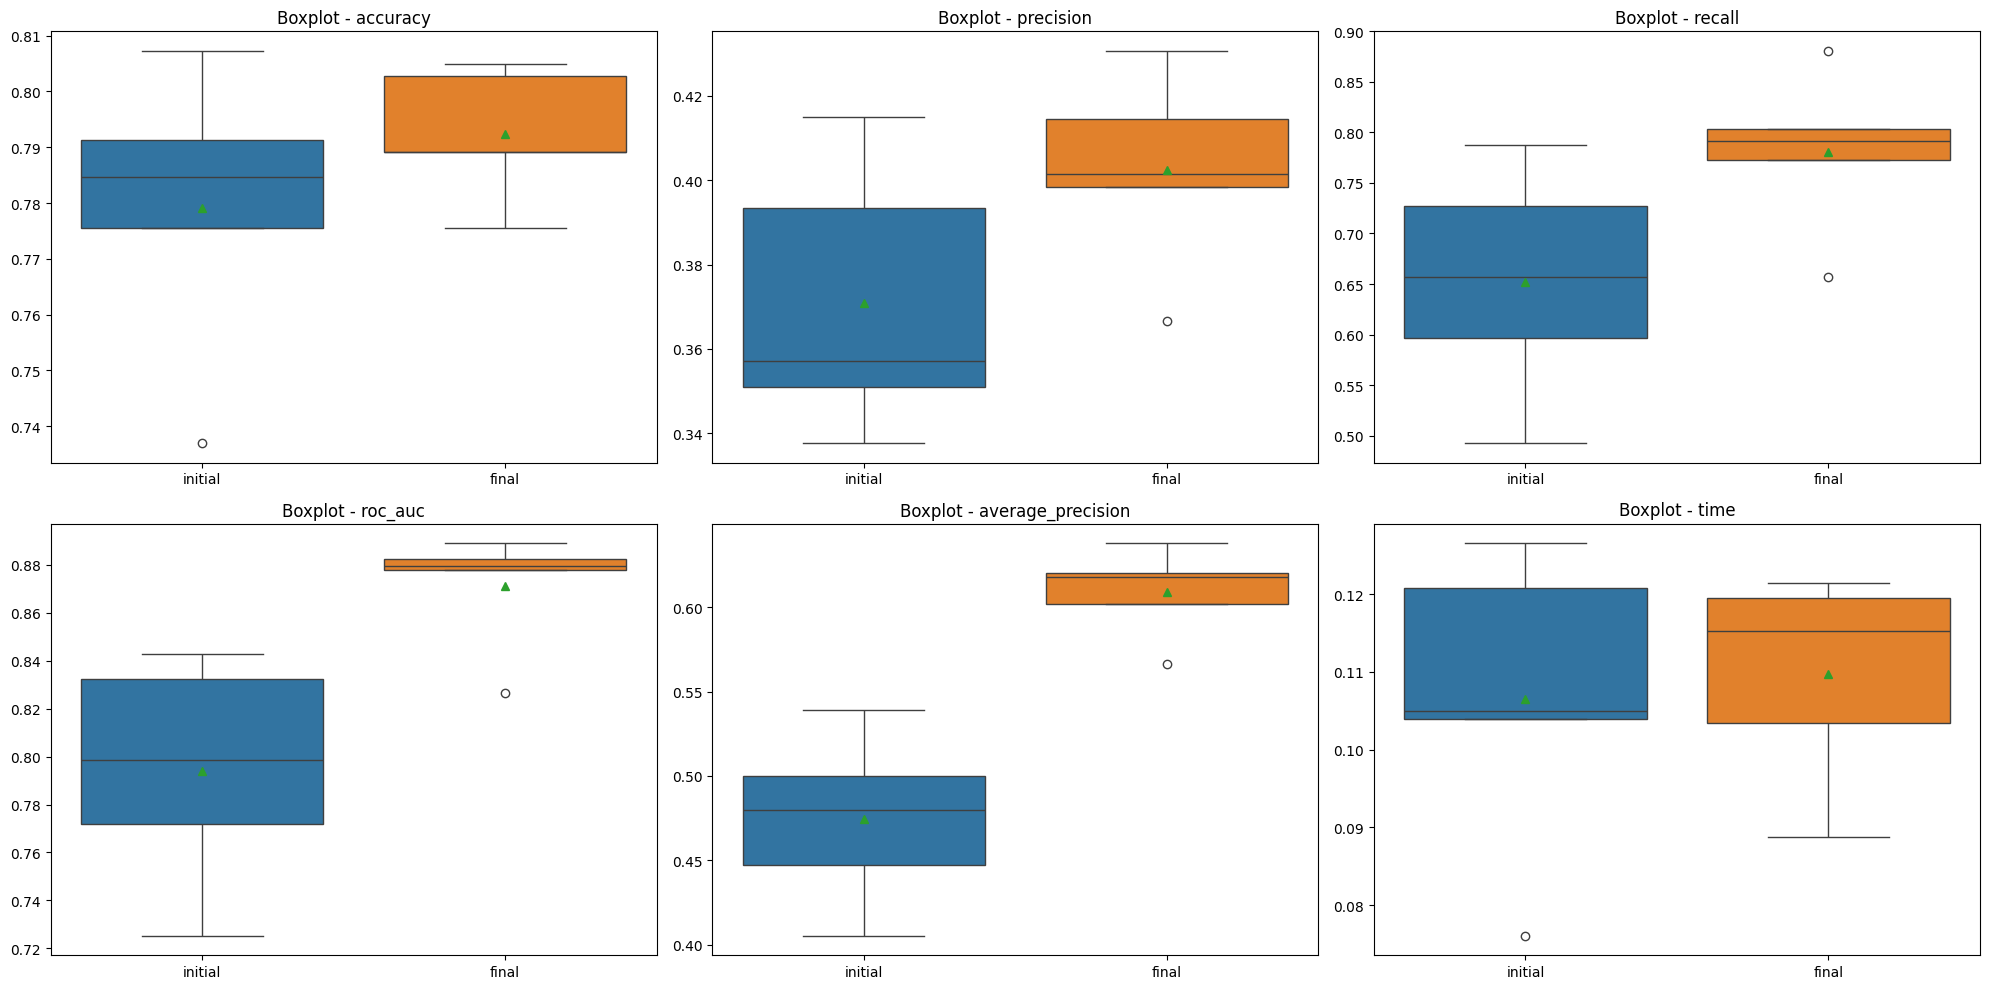

In [32]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_metrics, df_metrics.columns[1:].to_list(), 'results', 'results')

plt.savefig(f'../images/outputs/charts/pandas/nb08_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

## 08.7. Exportação do modelo otimizado

### 08.7.1. Salvando o grid search completo para auditoria e reprodutibilidade

In [33]:
joblib.dump(grid_search, consts.GRID_SEARCH_CLASSIFICATION_PANDAS_JOBLIB)

['../models/grid_search_classification_pandas.joblib']

### 08.7.2. Salvando o modelo final treinado com os melhores parâmetros encontrados pelo Grid Search nos formatos joblib e pkl

In [34]:
joblib.dump(pipeline_final, consts.MODEL_CLASSIFICATION_PANDAS_JOBLIB)

['../models/model_classification_pandas.joblib']

In [35]:
joblib.dump(pipeline_final, consts.MODEL_CLASSIFICATION_PANDAS_PKL)

['../models/model_classification_pandas.pkl']